In [1]:
import fair
fair.__version__

c:\Users\SetuPelz\Documents\GitHub\2023_carbondebt\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'2.2.0'

In [2]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import os
import logging

from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties

# Moving up one level as the ipynb is in the Code folder
os.chdir('..')

# turn off logging messages
logger = logging.getLogger('fair')
logger.setLevel(level=logging.CRITICAL)

In [3]:
# Thornhill is better for this calibration
f = FAIR(ch4_method="thornhill2021")
f.define_time(1750, 2100, 1)

In [4]:
# Load historical emissions (1750-2014)
emiss_hist = pd.read_csv("Data/fairparams/all_scaled_1750-2022.csv")

# Drop columns labelled from the years 2015 to 2022
years_to_drop = [str(year) for year in range(2015, 2023)]
emiss_hist = emiss_hist.drop(columns=years_to_drop, errors='ignore')

# Only keep the column 'variable' and the columns labelled from the years 1750 to 2014
years_to_keep = [str(year) for year in range(1750, 2015)]
emiss_hist = emiss_hist[['variable'] + years_to_keep]

# Set column names to sentence case
emiss_hist.columns = emiss_hist.columns.str.capitalize()

# Read in scenario data
emiss_scen = pd.read_csv("Data/pathways/scenarios/emiss_curpol_curpledge.csv")

# Mapping dictionary to merge historical and scenario emissions
mapping_dict = {
    'Emissions|BC': 'Emissions|BC',
    'Emissions|CH4': 'Emissions|CH4',
    'Emissions|CO': 'Emissions|CO',
    'Emissions|CO2': None, 
    'Emissions|CO2|AFOLU': 'Emissions|CO2|AFOLU',
    'Emissions|CO2|Energy and Industrial Processes': 'Emissions|CO2|Energy and Industrial Processes',
    'Emissions|F-Gases': None, 
    'Emissions|HFC': None,  
    'Emissions|HFC|HFC134a': 'Emissions|HFC-134a',
    'Emissions|HFC|HFC143a': 'Emissions|HFC-143a',
    'Emissions|HFC|HFC227ea': 'Emissions|HFC-227ea',
    'Emissions|HFC|HFC23': 'Emissions|HFC-23',
    'Emissions|HFC|HFC245ca': None, 
    'Emissions|HFC|HFC32': 'Emissions|HFC-32',
    'Emissions|HFC|HFC43-10': 'Emissions|HFC-4310mee',
    'Emissions|Kyoto Gases (AR6-GWP100)': None, 
    'Emissions|N2O': 'Emissions|N2O',
    'Emissions|NH3': 'Emissions|NH3',
    'Emissions|NOx': 'Emissions|NOx',
    'Emissions|OC': 'Emissions|OC',
    'Emissions|PFC|C2F6': 'Emissions|C2F6',
    'Emissions|PFC|C6F14': 'Emissions|C6F14',
    'Emissions|PFC|CF4': 'Emissions|CF4',
    'Emissions|SF6': 'Emissions|SF6',
    'Emissions|Sulfur': 'Emissions|Sulfur',
    'Emissions|VOC': 'Emissions|VOC',
}

# Rename emiss_scen rows in 'Variable' column to match the historical dataset
emiss_scen['Variable'] = emiss_scen['Variable'].replace(mapping_dict)

# Remove rows where 'Variable' did not match
emiss_scen = emiss_scen.dropna(subset=['Variable'])

# Combine historical and future emissions with a left join, common index is Variable
emiss = pd.merge(emiss_scen, emiss_hist, on="Variable", how="left")

# Drop rows where data is missing in historical or future
emiss = emiss.dropna()

# Mapping dictionary to prepare species names to match FaIR config file
mapping_dict_fair = {
    'Emissions|CO2|Energy and Industrial Processes': 'CO2 FFI',
    'Emissions|CO2|AFOLU': 'CO2 AFOLU',
    'Emissions|CO2': 'CO2', 
    'Emissions|CH4': 'CH4',
    'Emissions|N2O': 'N2O',
    'Emissions|Sulfur': 'Sulfur',
    'Emissions|BC': 'BC',
    'Emissions|OC': 'OC',
    'Emissions|NH3': 'NH3',
    'Emissions|NOx': 'NOx',
    'Emissions|VOC': 'VOC',
    'Emissions|CO': 'CO',
    'Emissions|CFC-11': 'CFC-11',  
    'Emissions|CFC-12': 'CFC-12',  
    'Emissions|CFC-113': 'CFC-113',  
    'Emissions|CFC-114': 'CFC-114',  
    'Emissions|CFC-115': 'CFC-115',  
    'Emissions|HCFC-22': 'HCFC-22',  
    'Emissions|HCFC-141b': 'HCFC-141b',  
    'Emissions|HCFC-142b': 'HCFC-142b',  
    'Emissions|CCl4': 'CCl4',  
    'Emissions|CHCl3': 'CHCl3',  
    'Emissions|CH2Cl2': 'CH2Cl2',  
    'Emissions|CH3Cl': 'CH3Cl',  
    'Emissions|CH3CCl3': 'CH3CCl3',  
    'Emissions|CH3Br': 'CH3Br',  
    'Emissions|Halon-1211': 'Halon-1211',  
    'Emissions|Halon-1301': 'Halon-1301',  
    'Emissions|Halon-2402': 'Halon-2402',  
    'Emissions|CF4': 'CF4',
    'Emissions|C2F6': 'C2F6',
    'Emissions|C3F8': 'C3F8',  
    'Emissions|c-C4F8': 'c-C4F8',  
    'Emissions|C4F10': 'C4F10',  
    'Emissions|C5F12': 'C5F12',  
    'Emissions|C6F14': 'C6F14',
    'Emissions|C7F16': 'C7F16',  
    'Emissions|C8F18': 'C8F18',  
    'Emissions|NF3': 'NF3',  
    'Emissions|SF6': 'SF6',
    'Emissions|SO2F2': 'SO2F2',  
    'Emissions|HFC-125': 'HFC-125',
    'Emissions|HFC-134a': 'HFC-134a',
    'Emissions|HFC-143a': 'HFC-143a',
    'Emissions|HFC-152a': 'HFC-152a',  
    'Emissions|HFC-227ea': 'HFC-227ea',
    'Emissions|HFC-23': 'HFC-23',
    'Emissions|HFC-236fa': 'HFC-236fa',  
    'Emissions|HFC-245fa': 'HFC-245fa',
    'Emissions|HFC-32': 'HFC-32',
    'Emissions|HFC-365mfc': 'HFC-365mfc',  
    'Emissions|HFC-4310mee': 'HFC-4310mee'
}

# Rename emiss_scen rows in 'Variable' column to match the historical dataset
emiss['Variable'] = emiss['Variable'].replace(mapping_dict_fair)

# Re arrange columns so that the columns from 2015 to 2100 are at the end, and 1750-2014 after 'Unit'
emiss = emiss[['Model', 'Scenario', 'Region', 'Variable', 'Unit'] + list(emiss.columns[18:]) + list(emiss.columns[5:18])]

# Only keep those scenarios we want to run
def assign_case(row):
    if row['Model'] == "Current policies" and all(x in row['Scenario'] for x in ["KyotoFromPrice_incrate2", "Median"]) and row['Scenario'].endswith("NPi"):
        return "A"
    elif row['Model'] == "NDC case - unconditional" and all(x in row['Scenario'] for x in ["KyotoFromPrice_incrate3", "nz_all_GHG", "cert_allconf_0.1", "Median"]):
        return "E"
    return None

# Apply the function and filter
emiss['Case'] = emiss.apply(assign_case, axis=1)
emiss = emiss[emiss['Case'].isin(['A', 'E'])]

# Bring column 'Case' to front
emiss = emiss[['Case'] + list(emiss.columns[:-1])]

# Write to csv
emiss.to_csv("Data/pathways/scenarios/emiss_curpol_curpledge_hist.csv", index=False)

In [5]:
emiss

,Case,Model,Scenario,Region,Variable,Unit,1750,1751,1752,1753,...,2030,2040,2045,2050,2053,2060,2070,2080,2090,2100
886,A,Current policies,Median|Harmonized|KyotoFromPrice_incrate2_MESS...,World,BC,Mt BC/yr,2.096766,2.071972,2.067178,2.070382,...,6.892077,5.664298,5.043576,4.422854,4.232210,3.787373,3.126010,2.475663,1.924835,1.848398
887,A,Current policies,Median|Harmonized|KyotoFromPrice_incrate2_MESS...,World,CH4,Mt CH4/yr,38.246272,38.106144,38.070994,38.237775,...,344.795313,314.797466,290.900881,267.004295,258.166099,237.543643,213.785051,194.110408,165.212728,169.749300
888,A,Current policies,Median|Harmonized|KyotoFromPrice_incrate2_MESS...,World,CO,Mt CO/yr,348.454973,343.853051,342.423860,343.601163,...,799.640608,701.381678,640.815791,580.249904,551.828848,485.513051,416.118401,347.721111,284.022725,268.117940
889,A,Current policies,Median|Harmonized|KyotoFromPrice_incrate2_MESS...,World,CO2 AFOLU,Mt CO2/yr,10.992174,32.976522,54.960869,76.945217,...,2678.586308,1669.925470,913.890027,157.854584,-329.342998,-1466.137355,-2969.495387,-4086.403237,-5112.456959,-5111.914763
890,A,Current policies,Median|Harmonized|KyotoFromPrice_incrate2_MESS...,World,CO2 FFI,Mt CO2/yr,9.306084,9.407378,9.505318,9.610642,...,39888.862452,42457.539192,44923.714246,47389.889300,49207.687858,53449.217827,58211.399954,65075.250030,74013.892845,81837.418541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6619,E,NDC case - unconditional,Median|Harmonized|KyotoFromPrice_incrate3_REMI...,World,C6F14,kt C6F14/yr,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6620,E,NDC case - unconditional,Median|Harmonized|KyotoFromPrice_incrate3_REMI...,World,CF4,kt CF4/yr,0.000000,0.000000,0.000000,0.000000,...,6.908783,0.885240,0.884758,0.939960,0.859964,0.722188,0.708619,0.548553,0.471891,0.503015
6621,E,NDC case - unconditional,Median|Harmonized|KyotoFromPrice_incrate3_REMI...,World,SF6,kt SF6/yr,0.000000,0.000000,0.000000,0.000000,...,10.479241,1.033103,0.840119,0.689009,0.668434,0.631069,0.679168,0.577141,0.529167,0.534410
6622,E,NDC case - unconditional,Median|Harmonized|KyotoFromPrice_incrate3_REMI...,World,Sulfur,Mt SO2/yr,2.293965,2.262805,2.257382,2.266406,...,73.878225,36.577950,25.293318,19.383379,18.718322,17.155667,15.788632,15.190747,14.406048,13.675025


In [6]:
# Determine scenarios 
scenarios = emiss.Scenario.unique().tolist()

# Set scenarios
f.define_scenarios(scenarios)

In [7]:
# Load config parameters
fair_params_1_4_1_file = 'data/fairparams/calibrated_constrained_parameters_calibration1.4.1.csv'
df_configs = pd.read_csv(fair_params_1_4_1_file, index_col=0)
configs = df_configs.index  # this is used as a label for the "config" axis
f.define_configs(configs)

In [8]:
# Load full species configuration file
species_config = pd.read_csv('data/fairparams/species_configs_properties_calibration1.4.1.csv')

# List of species that are always considered
always_considered = [
    'CO2', 'Solar', 'Volcanic', 'Aerosol-radiation interactions', 'Aerosol-cloud interactions',
    'Ozone', 'Light absorbing particles on snow and ice', 'Stratospheric water vapour',
    'Land use', 'Equivalent effective stratospheric chlorine', 'Montreal gases'
]

# Run species_config to only include those in 'emiss' DataFrame or the always considered species
species_config_run = species_config.loc[
    species_config['name'].isin(emiss['Variable'].unique()) | species_config['name'].isin(always_considered)
]

# Save the run to a new CSV file
species_config_run.to_csv('data/fairparams/species_configs_properties_calibration1.4.1_run.csv', index=False)

# Load the run species configuration and provide it to the FAIR object
fair_species_configs_1_4_1_file = 'data/fairparams/species_configs_properties_calibration1.4.1_run.csv'
species, properties = read_properties(filename=fair_species_configs_1_4_1_file)

# Define species in the FAIR model
f.define_species(species, properties)

In [9]:
# Set up all of the xarrays we need
f.allocate()

In [10]:
# Set up EESC for run
eesc = pd.read_csv('data/fairparams/eesc.csv')
eesc = pd.concat([eesc]*len(scenarios), ignore_index=True)
eesc['Scenario'] = np.repeat(scenarios, len(eesc) // len(scenarios))
eesc = eesc[['Scenario'] + list(eesc.columns[:-1])]
eesc.to_csv('data/fairparams/eesc_run.csv', index=False)

# Set up volcanic, solar and montreal forcing for desired scenarios (there are three rows for each scenario)
volcanic_solar = pd.read_csv('data/fairparams/volcanic_solar.csv')
volcanic_solar = pd.concat([volcanic_solar]*len(scenarios), ignore_index=True)
volcanic_solar['Scenario'] = np.repeat(scenarios, len(volcanic_solar) // len(scenarios))
volcanic_solar = volcanic_solar[['Scenario'] + list(volcanic_solar.columns[:-1])]
volcanic_solar.to_csv('data/fairparams/volcanic_solar_run.csv', index=False)

In [11]:
# Add in emissions and forcing data
f.fill_from_csv(
    emissions_file='Data/pathways/scenarios/emiss_curpol_curpledge_hist.csv',
    concentration_file='Data/fairparams/eesc_run.csv', 
    forcing_file='Data/fairparams/volcanic_solar_run.csv', # Consider stopping solar forcing at 2022 and zeroes after that
)

# Ensure that the solar and volcanic scale factors are picked up (always run)
fill(
    f.forcing,
    f.forcing.sel(specie="Volcanic") * df_configs["forcing_scale[Volcanic]"].values.squeeze(),
    specie="Volcanic",
)
fill(
    f.forcing,
    f.forcing.sel(specie="Solar") * df_configs["forcing_scale[Solar]"].values.squeeze(),
    specie="Solar",
)

In [12]:
# Add in parameters
f.fill_species_configs('Data/fairparams/species_configs_properties_calibration1.4.1_run.csv')
f.override_defaults('Data/fairparams/calibrated_constrained_parameters_calibration1.4.1.csv')

In [13]:
f.species_configs['forcing_reference_concentration'].sel(config=f.configs[0])

<xarray.DataArray 'forcing_reference_concentration' (specie: 32)> Size: 256B
array([   nan,    nan, 277.15, 731.41, 273.87,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,  34.05,   0.  ,   0.  ,   0.  ,
         0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,   0.  ,    nan])
Coordinates:
    config   int64 8B 1234
  * specie   (specie) <U43 6kB 'CO2 FFI' 'CO2 AFOLU' ... 'Montreal gases'

In [14]:
# Initialise the run
initialise(f.concentration, f.species_configs["baseline_concentration"])
initialise(f.forcing, 0)
initialise(f.temperature, 0)
initialise(f.cumulative_emissions, 0)
initialise(f.airborne_emissions, 0)
initialise(f.ocean_heat_content_change, 0)

In [15]:
# Run fair
f.run()

Running 3364 projections in parallel: 100%|██████████| 350/350 [00:08<00:00, 39.07timesteps/s]


In [16]:
f.ghg_method

'meinshausen2020'

In [17]:
f.emissions.sel(scenario=f.scenarios[0], config=f.configs[0], timepoints=1751.5)

<xarray.DataArray (specie: 32)> Size: 256B
array([9.45634805e-03, 4.39686954e-02, 5.34250434e-02, 3.80885690e+01,
       9.88471297e-01, 2.26009358e+00, 2.06957494e+00, 1.51249201e+01,
       6.57141119e+00, 1.92251582e+01, 5.95291641e+01, 3.43138456e+02,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan])
Coordinates:
    timepoints  float64 8B 1.752e+03
    scenario    <U98 392B 'Median|Harmonized|KyotoFromPrice_incrate2_MESSAGEi...
    config      int64 8B 1234
  * specie      (specie) <U43 6kB 'CO2 FFI' 'CO2 AFOLU' ... 'Montreal gases'

In [18]:
f.species_configs['forcing_reference_concentration'].sel(config=f.configs[0])

<xarray.DataArray 'forcing_reference_concentration' (specie: 32)> Size: 256B
array([   nan,    nan, 277.15, 731.41, 273.87,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,  34.05,   0.  ,   0.  ,   0.  ,
         0.  ,   0.  ,   0.  ,   0.  ,   0.  ,   0.  ,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,   0.  ,    nan])
Coordinates:
    config   int64 8B 1234
  * specie   (specie) <U43 6kB 'CO2 FFI' 'CO2 AFOLU' ... 'Montreal gases'

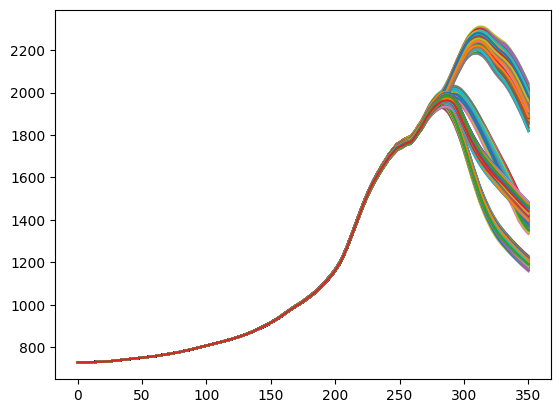

In [19]:
for scenario in f.scenarios:
    pl.plot(f.concentration.sel(specie='CH4', scenario=scenario))

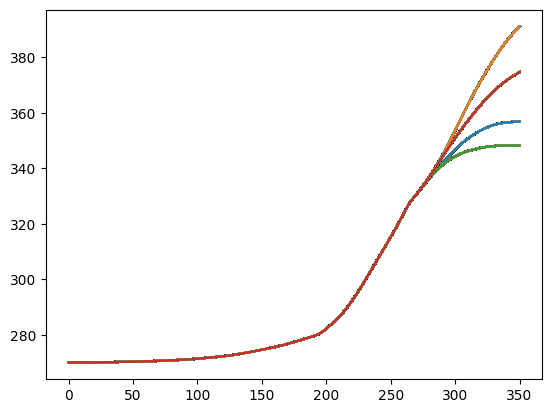

In [20]:
for scenario in f.scenarios:
    pl.plot(f.concentration.sel(specie='N2O', scenario=scenario))

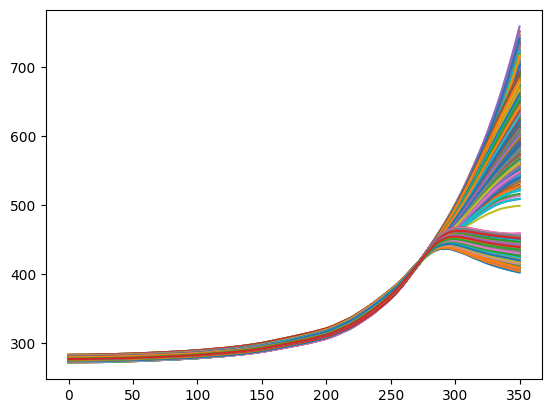

In [21]:
for scenario in f.scenarios:
    pl.plot(f.concentration.sel(specie='CO2', scenario=scenario))

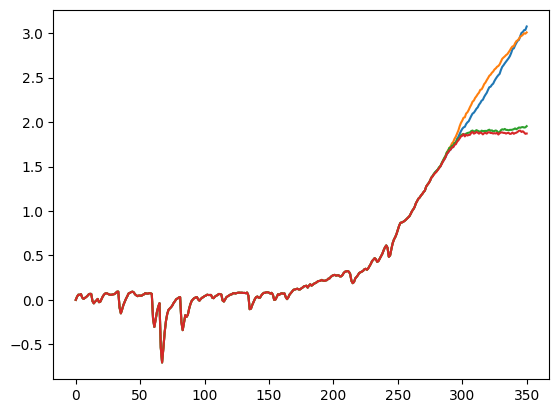

In [22]:
for scenario in f.scenarios:
    pl.plot(f.temperature.sel(scenario=scenario, layer=0).median(dim='config'))

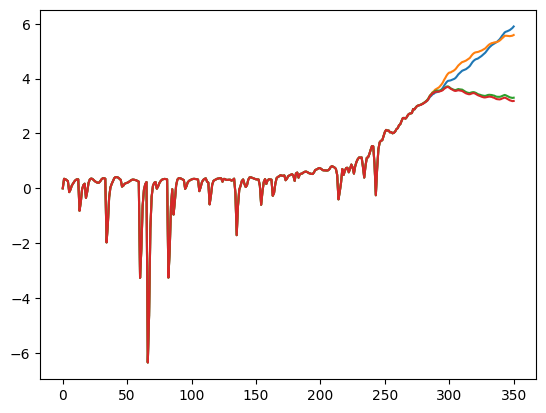

In [23]:
for scenario in f.scenarios:
    pl.plot(f.forcing_sum.sel(scenario=scenario).median(dim='config'))

In [24]:
for specie in f.species:
    print(specie, f.forcing.sel(scenario=f.scenarios[0], specie=specie, timebounds=2020).median(dim='config').values)

CO2 FFI nan
CO2 AFOLU nan
CO2 2.172833755698272
CH4 0.5568121730845392
N2O 0.20599987166147163
Sulfur nan
BC nan
OC nan
NH3 nan
NOx nan
VOC nan
CO nan
CF4 0.005057548921814476
C2F6 0.0012634860342506933
C6F14 9.663043960291222e-05
SF6 0.005707504636628667
HFC-134a 0.021626685905783222
HFC-143a 0.005363516873722865
HFC-227ea 0.0004936366586038858
HFC-23 0.006079726759451832
HFC-32 0.0034023319497806306
HFC-4310mee 0.00015353485924425066
Solar -0.022457834713236875
Volcanic 0.12669743230059682
Aerosol-radiation interactions -0.2051634055378607
Aerosol-cloud interactions -0.9064354408482151
Ozone 0.4674244108111457
Light absorbing particles on snow and ice 0.09446527777566883
Stratospheric water vapour 0.05323463164301441
Land use -0.1938628125629065
Equivalent effective stratospheric chlorine nan
Montreal gases 0.353647114


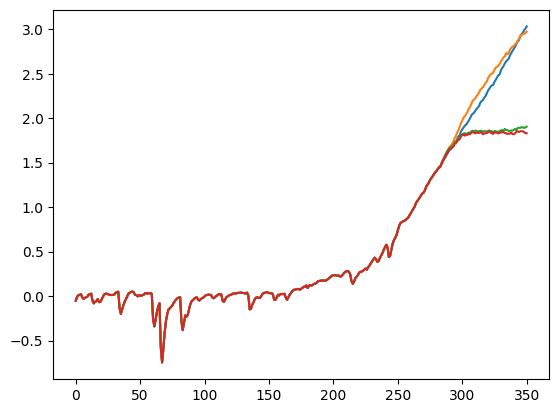

In [25]:
for scenario in f.scenarios:
    pl.plot(
        (
            f.temperature.sel(scenario=scenario, layer=0) -
            f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850,1901)).mean(dim='timebounds')
        ).median(dim='config')
    )

In [26]:
# Determine temperature response quantiles relative to 1850-1901

# Set quantiles
quantiles = [0.1, 0.167, 0.2, 0.3, 0.33, 0.4, 0.5, 0.6, 0.66, 0.7, 0.8, 0.833, 0.9]

# Extract temperature response
temperature_response = {}
for scenario in f.scenarios:
    temperature_response[scenario] = (
        f.temperature.sel(scenario=scenario, layer=0) -
        f.temperature.sel(scenario=scenario, layer=0, timebounds=np.arange(1850,1901)).mean(dim='timebounds')
    ).quantile(quantiles, dim='config').rename('Temperature response')

# Convert to IAMC format
temperature_response_df = pd.concat(
    [temperature_response[scenario].to_dataframe().unstack() for scenario in f.scenarios],
    keys=f.scenarios,
    names=['Scenario']
).reset_index().rename(columns={'level_1': 'Quantile'})
temperature_response_df.columns = ['Scenario', 'Quantile'] + [f'{year:.0f}' for year in f.temperature.timebounds.values]

# Save as CSV
temperature_response_df.to_csv('Data/pathways/scenarios/emiss_curpol_curpledge_temps.csv', index=False)

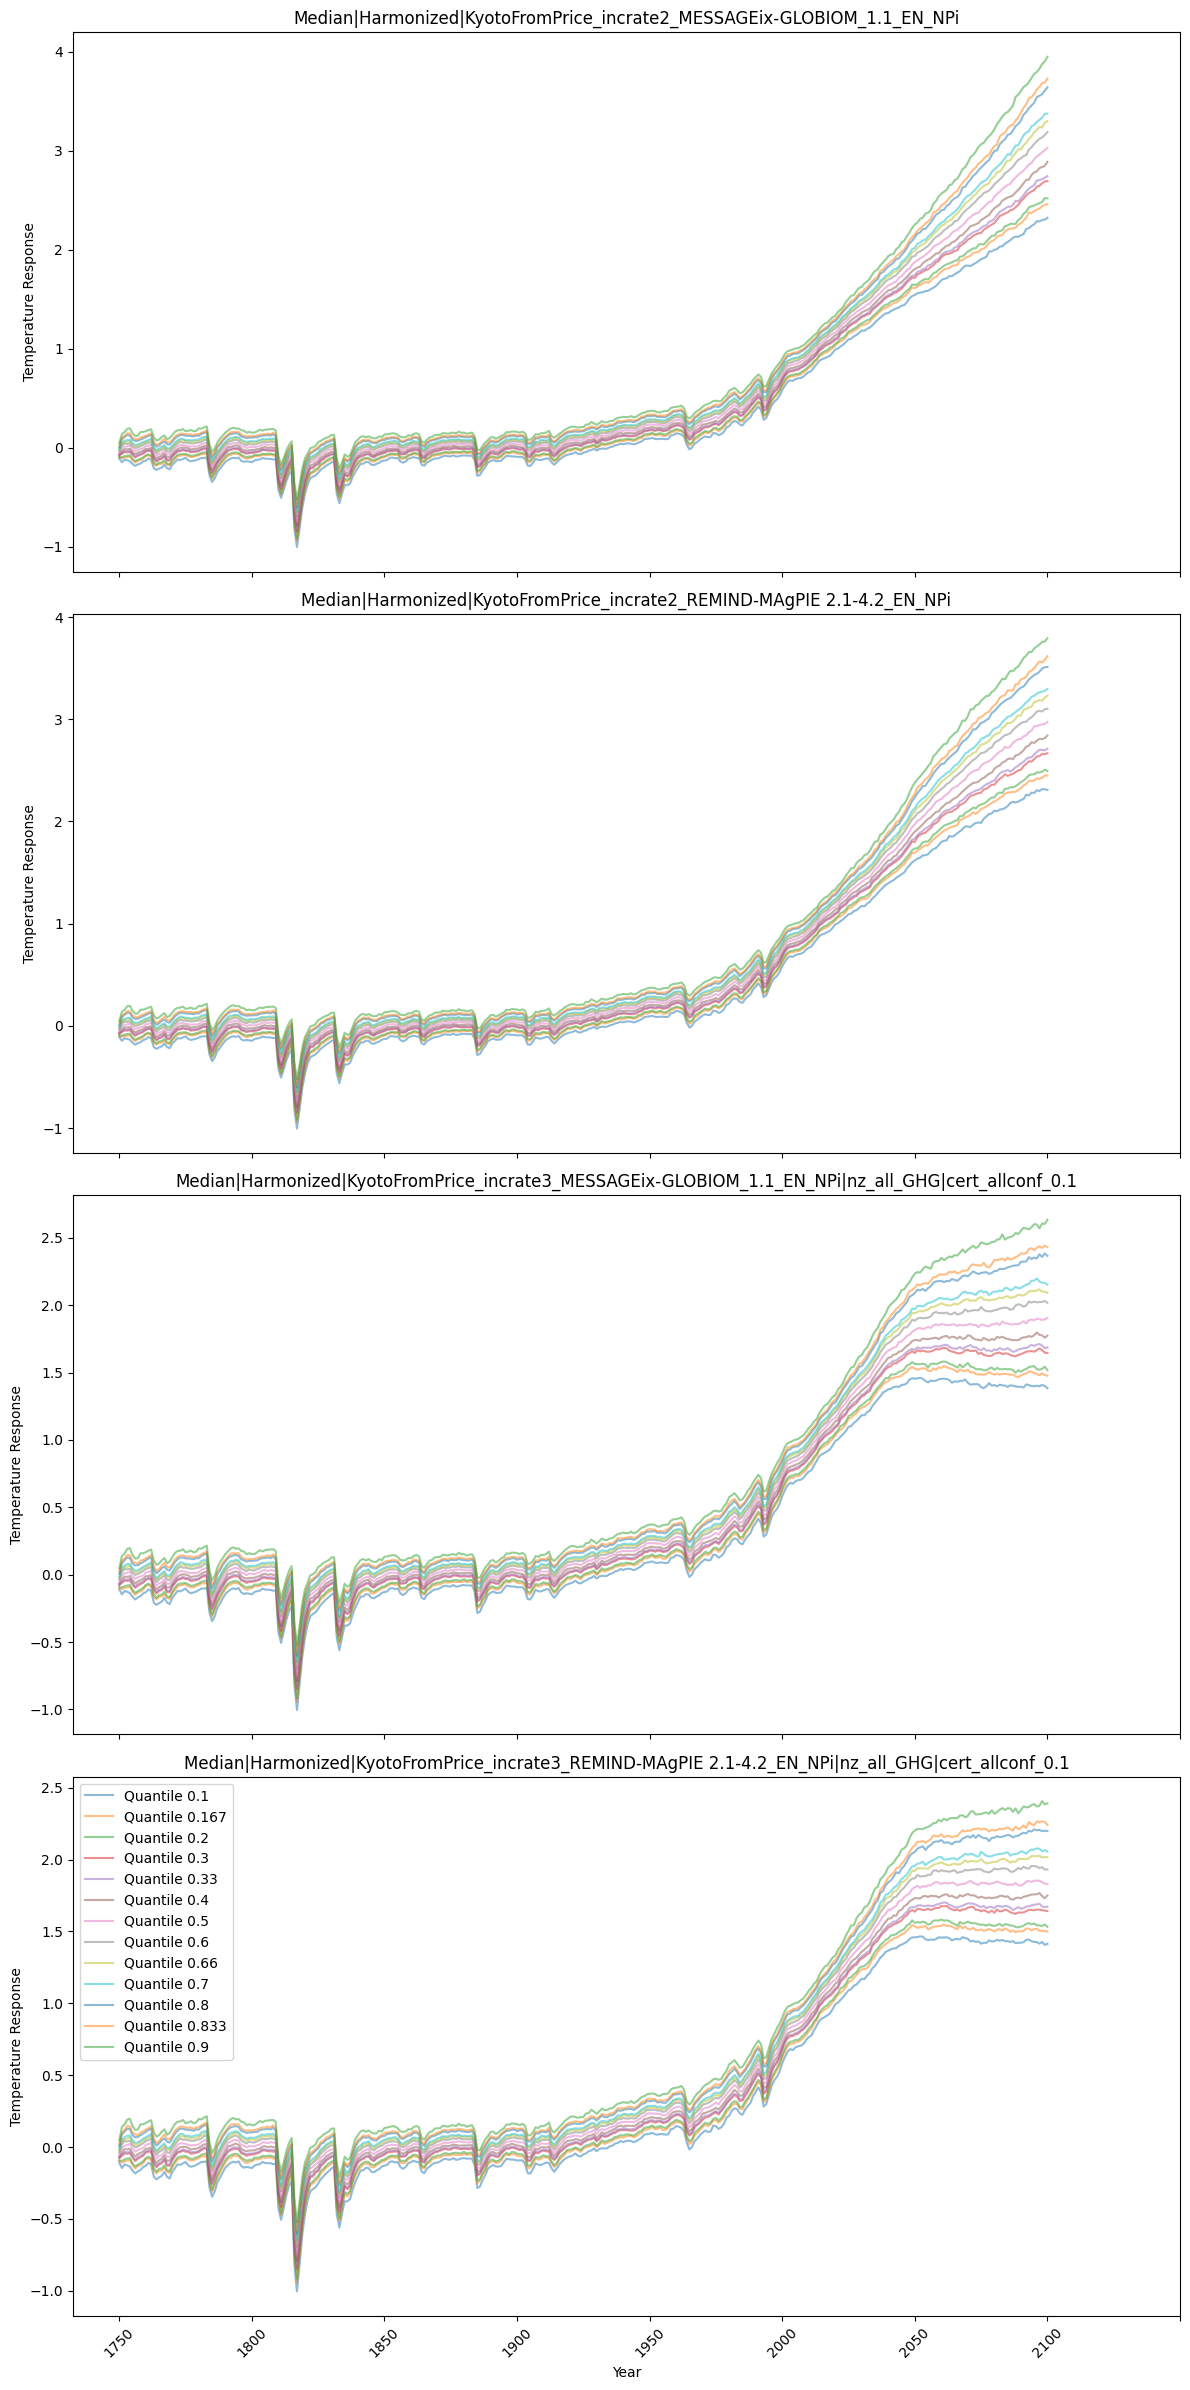

In [27]:
# Visualise temperature response quantiles 
fig, axes = pl.subplots(len(f.scenarios), 1, figsize=(12, 6 * len(f.scenarios)), sharex=True)

# Ensure axes is always iterable
if len(f.scenarios) == 1:
    axes = [axes]

for i, scenario in enumerate(f.scenarios):
    ax = axes[i]
    scenario_df = temperature_response_df[temperature_response_df['Scenario'] == scenario]
    for quantile in scenario_df['Quantile'].unique():
        quantile_df = scenario_df[scenario_df['Quantile'] == quantile]
        ax.plot(
            quantile_df.columns[2:], 
            quantile_df.iloc[0, 2:], 
            label=f'Quantile {quantile}',
            alpha=0.5,
        )
    ax.set_title(scenario)
    ax.set_ylabel('Temperature Response')
    ax.set_xticks(np.arange(0, 450, 50))  
    ax.tick_params(axis='x', rotation=45) 
    if i == len(f.scenarios) - 1:
        ax.set_xlabel('Year')

pl.tight_layout()
pl.legend()
pl.show()